In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [4]:
df=pd.read_csv("/content/Sample - Superstore.csv",encoding='latin1')

In [5]:
df


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9989,9990,CA-2014-110422,1/21/2014,1/23/2014,Second Class,TB-21400,Tom Boeckenhauer,Consumer,United States,Miami,...,33180,South,FUR-FU-10001889,Furniture,Furnishings,Ultra Door Pull Handle,25.2480,3,0.20,4.1028
9990,9991,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,FUR-FU-10000747,Furniture,Furnishings,Tenex B1-RE Series Chair Mats for Low Pile Car...,91.9600,2,0.00,15.6332
9991,9992,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,TEC-PH-10003645,Technology,Phones,Aastra 57i VoIP phone,258.5760,2,0.20,19.3932
9992,9993,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,OFF-PA-10004041,Office Supplies,Paper,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",29.6000,4,0.00,13.3200


In [6]:
print('info: ',df.info)
print("shape:",df.shape)
print('columns: ',df.columns.to_list())
print("\nData types :",df.dtypes)
print('/n Missing Values:',df.isnull().sum())
print("/n First 5 values:",df.head())


info:  <bound method DataFrame.info of       Row ID        Order ID  Order Date   Ship Date       Ship Mode  \
0          1  CA-2016-152156   11/8/2016  11/11/2016    Second Class   
1          2  CA-2016-152156   11/8/2016  11/11/2016    Second Class   
2          3  CA-2016-138688   6/12/2016   6/16/2016    Second Class   
3          4  US-2015-108966  10/11/2015  10/18/2015  Standard Class   
4          5  US-2015-108966  10/11/2015  10/18/2015  Standard Class   
...      ...             ...         ...         ...             ...   
9989    9990  CA-2014-110422   1/21/2014   1/23/2014    Second Class   
9990    9991  CA-2017-121258   2/26/2017    3/3/2017  Standard Class   
9991    9992  CA-2017-121258   2/26/2017    3/3/2017  Standard Class   
9992    9993  CA-2017-121258   2/26/2017    3/3/2017  Standard Class   
9993    9994  CA-2017-119914    5/4/2017    5/9/2017    Second Class   

     Customer ID     Customer Name    Segment        Country             City  \
0       CG-1252

In [7]:
print('Basic Stats:',df.describe())

Basic Stats:             Row ID   Postal Code         Sales     Quantity     Discount  \
count  9994.000000   9994.000000   9994.000000  9994.000000  9994.000000   
mean   4997.500000  55190.379428    229.858001     3.789574     0.156203   
std    2885.163629  32063.693350    623.245101     2.225110     0.206452   
min       1.000000   1040.000000      0.444000     1.000000     0.000000   
25%    2499.250000  23223.000000     17.280000     2.000000     0.000000   
50%    4997.500000  56430.500000     54.490000     3.000000     0.200000   
75%    7495.750000  90008.000000    209.940000     5.000000     0.200000   
max    9994.000000  99301.000000  22638.480000    14.000000     0.800000   

            Profit  
count  9994.000000  
mean     28.656896  
std     234.260108  
min   -6599.978000  
25%       1.728750  
50%       8.666500  
75%      29.364000  
max    8399.976000  


In [8]:
# 1. Check unique values in key columns
print(df['Category'].unique())
print(df['Region'].unique())
print(df['Segment'].unique())

['Furniture' 'Office Supplies' 'Technology']
['South' 'West' 'Central' 'East']
['Consumer' 'Corporate' 'Home Office']


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [10]:
df['Order Date']=pd.to_datetime(df['Order Date'])
df['Ship Date']=pd.to_datetime(df['Ship Date'])

In [11]:
df['year']=df['Order Date'].dt.year
df['month']=df['Order Date'].dt.month
df['Profit Margin']=(df['Profit']/df['Sales'])*100

In [12]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,year,month,Profit Margin
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,2016,11,16.00
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,2016,11,30.00
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,2016,6,47.00
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2015,10,-40.00
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,2015,10,11.25


In [13]:
print(f"Year range :{df['year'].min()} to {df['year'].max()}")
print("\n Updated columns:",df.columns.to_list())

Year range :2014 to 2017

 Updated columns: ['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit', 'year', 'month', 'Profit Margin']


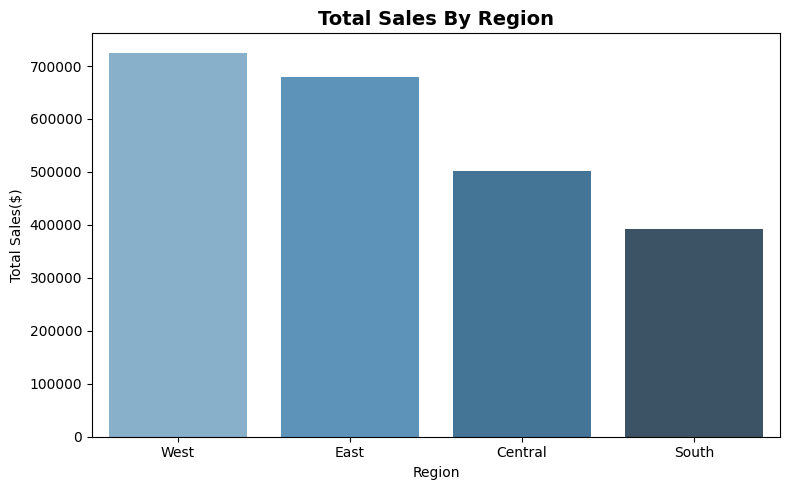

In [14]:
plt.figure(figsize=(8,5))
region_sales=df.groupby('Region')['Sales'].sum().sort_values(ascending=False)
sns.barplot(x=region_sales.index,y=region_sales.values,palette='Blues_d')
plt.title("Total Sales By Region",fontsize=14, fontweight='bold')
plt.ylabel("Total Sales($)")
plt.xlabel('Region')
plt.tight_layout()
plt.show()

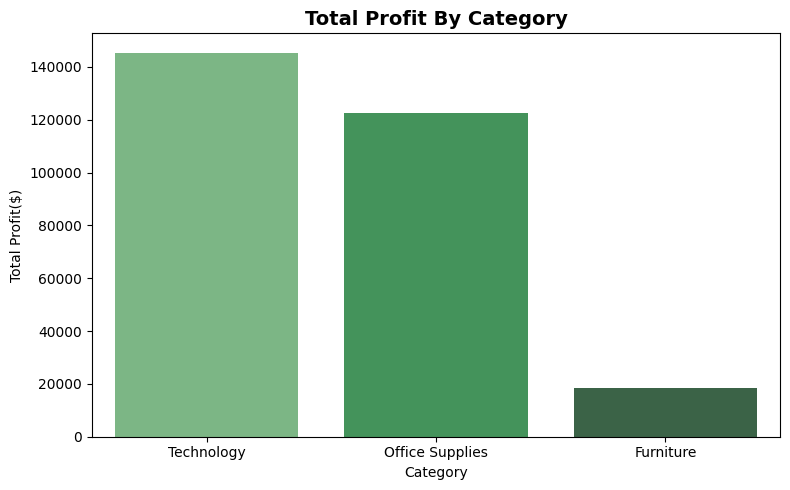

In [15]:
plt.figure(figsize=(8,5))
category_profit=df.groupby('Category')['Profit'].sum().sort_values(ascending=False)
sns.barplot(x=category_profit.index,y=category_profit.values,palette='Greens_d')
plt.title("Total Profit By Category",fontsize=14, fontweight='bold')
plt.ylabel("Total Profit($)")
plt.xlabel('Category')
plt.tight_layout()
plt.show()

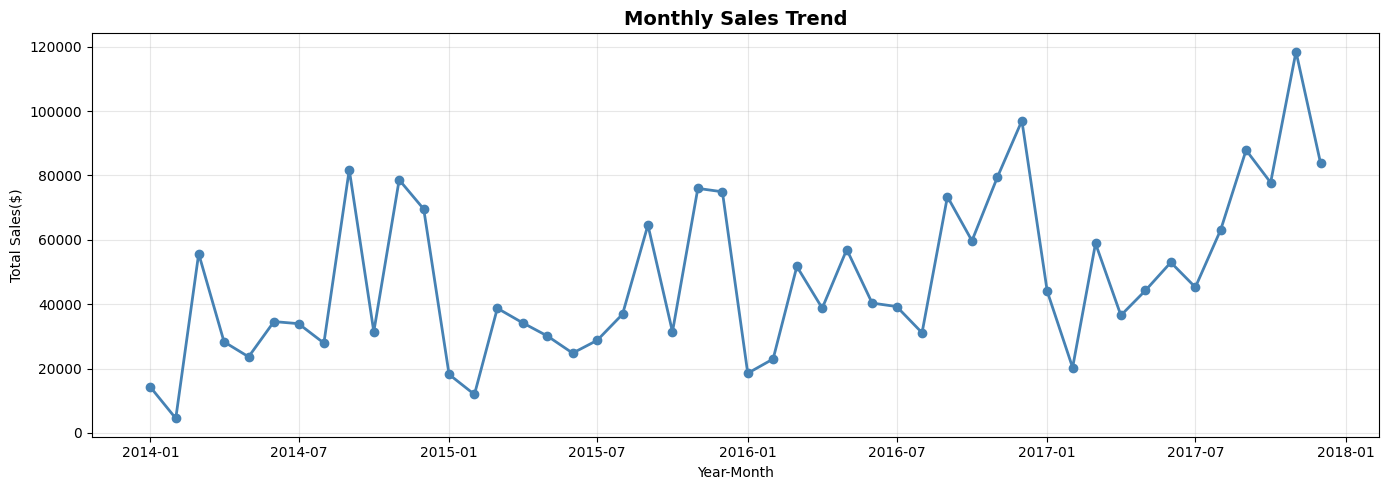

In [17]:
#Monthly Sales Trend
monthly_sales=df.groupby(['year','month'])['Sales'].sum().reset_index()
monthly_sales['date']=pd.to_datetime(monthly_sales[['year','month']].assign(DAY=1))

plt.figure(figsize=(14,5))
plt.plot(monthly_sales['date'],monthly_sales['Sales'],marker='o',linewidth=2,color='steelblue')
plt.title('Monthly Sales Trend',fontsize=14,fontweight='bold')
plt.xlabel("Year-Month")
plt.ylabel("Total Sales($)")
plt.grid(True,alpha=0.3)
plt.tight_layout()
plt.show()



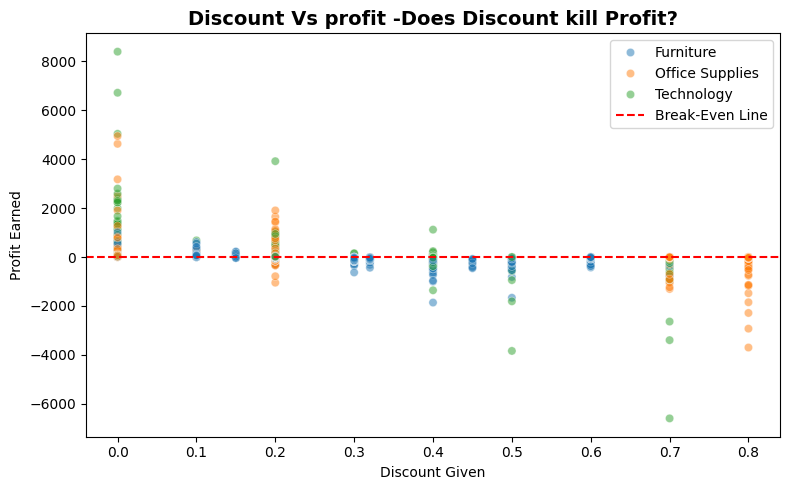

In [18]:
#Discount Vs Profit
plt.figure(figsize=(8,5))
sns.scatterplot(data=df,x='Discount',y='Profit',hue='Category',alpha=0.5)
plt.axhline(y=0,color='red',linestyle='--',label='Break-Even Line')
plt.title('Discount Vs profit -Does Discount kill Profit?',fontsize=14,fontweight='bold')
plt.xlabel('Discount Given')
plt.ylabel('Profit Earned')
plt.legend()
plt.tight_layout()
plt.show()



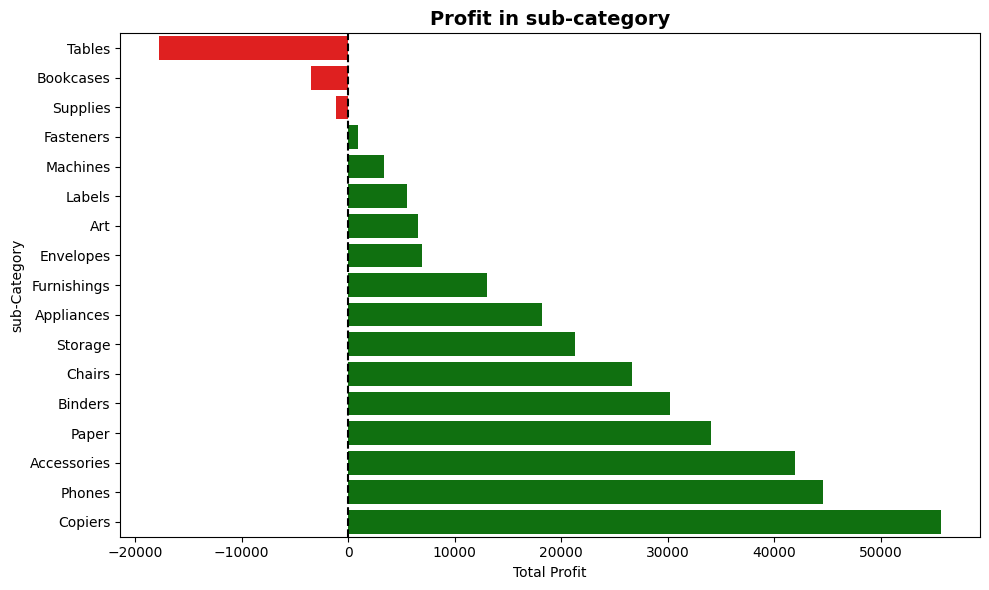

In [19]:
#Top 10 Most Profitable Categories
plt.figure(figsize=(10,6))
sub_profit=df.groupby('Sub-Category')['Profit'].sum().sort_values()
colors=['red'if x<0 else 'green' for x in sub_profit.values]
sns.barplot(x=sub_profit.values,y=sub_profit.index,palette=colors)
plt.title("Profit in sub-category",fontsize=14,fontweight='bold')
plt.xlabel('Total Profit')
plt.ylabel('sub-Category')
plt.axvline(x=0,color='black',linestyle='--')
plt.tight_layout()
plt.show()


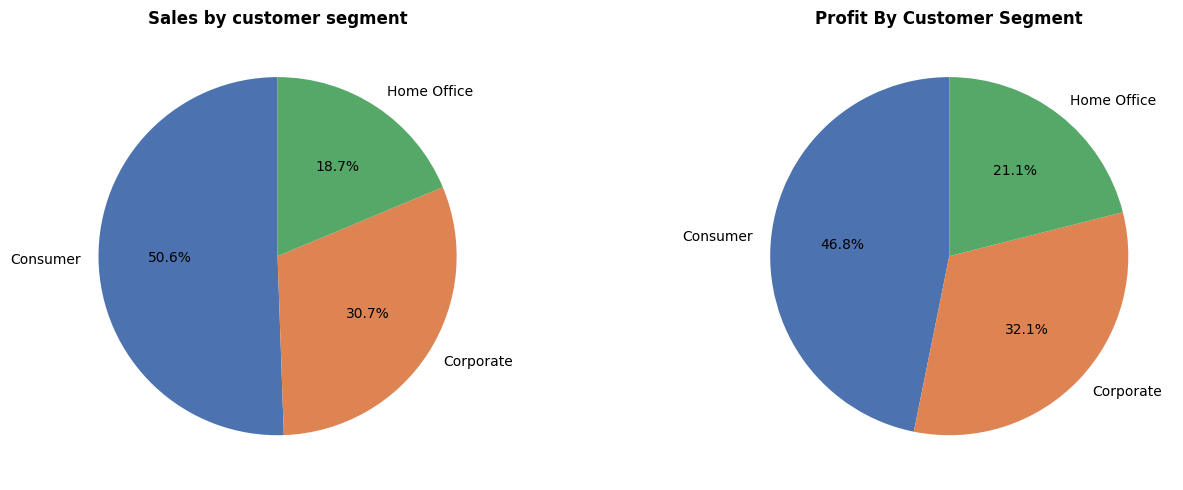

In [20]:
#Customer Segment Analysis
fig,axes=plt.subplots(1,2,figsize=(14,5))
segment_sales=df.groupby('Segment')['Sales'].sum()
axes[0].pie(segment_sales,labels=segment_sales.index,autopct='%1.1f%%',colors=['#4C72B0','#DD8452','#55A868'],startangle=90)
axes[0].set_title("Sales by customer segment",fontweight='bold')

segment_profit=df.groupby('Segment')['Profit'].sum()
axes[1].pie(segment_profit,labels=segment_profit.index,autopct='%1.1f%%',colors=['#4C72B0','#DD8452','#55A868'],startangle=90)
axes[1].set_title('Profit By Customer Segment',fontweight='bold')

plt.tight_layout()
plt.show()

In [22]:
#key Buisness Insights

print('='*50)
print("Key Buisness Insights -Superstore Data")
print('='*50)

print(f"\n1. Highest Sales Region : {region_sales.idxmax()}"
      f"(${region_sales.max():,.0f})")

print(f"\n2. Most Profitable Category :{category_profit.idxmax()}"
       f"(${category_profit.max():,.0f})")

print(f"\n3. Least Profitable Category :{category_profit.idxmin()}"
       f"(${category_profit.min():,.0f})")

loss_orders = df[df['Profit']<0].shape[0]
print(f"\n4. Loss Making orders :,{loss_orders}"
      f"({loss_orders/len(df)*100:.1f}% of all orders)")

high_discount = df[df['Discount']>0.4]
print(f"\n5. Orders with 40%+ Discount : {len(high_discount)}-- "
      f"Avg Profit : ${high_discount['Profit'].mean():,.1f}")

print(f"\n6. Total revenue : {df['Sales'].sum():,.0f}")
print(f' Total Profit : {df['Profit'].sum():,.0f}')
print(f"Overall Margin : {(df['Profit'].sum()/df['Sales'].sum()*100):,.1f}%")
print('='*50)

Key Buisness Insights -Superstore Data

1. Highest Sales Region : West($725,458)

2. Most Profitable Category :Technology($145,455)

3. Least Profitable Category :Furniture($18,451)

4. Loss Making orders :,1871(18.7% of all orders)

5. Orders with 40%+ Discount : 933-- Avg Profit : $-106.7

6. Total revenue : 2,297,201
 Total Profit : 286,397
Overall Margin : 12.5%


In [26]:
from google.colab import files


In [27]:
df.to_csv('superstore_data.csv', index=False)
files.download('superstore_data.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>